In [ ]:
!pip install pandas scikit-learn numpy m2cgen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 2.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Aggregrated_Data.csv to Aggregrated_Data.csv


In [ ]:
dataset = pd.read_csv("/content/Aggregrated_Data.csv")
dataset.head()

,timestamp,satellite_prn,satellite_elevation_deg,satellite_azimuth_deg,temperature_C,humidity_%,rain_intensity_mm_hr,rain_sensor_value,snr_measured_dbhz,label
0,2024-01-01 00:00,8.23,44.94,313.18,34.99,58.64,0.00,0.00,51,0
1,2024-01-01 00:00,2.94,22.20,200.38,33.96,55.17,0.57,0.00,47,0
2,2024-01-01 00:00,11.30,26.44,162.51,32.92,50.66,0.00,0.00,42,0
3,2024-01-01 00:00,26.70,77.68,58.32,31.32,40.02,1.36,0.00,44,0
4,2024-01-01 00:00,21.89,82.50,54.38,28.65,89.37,2.79,49.88,39,1


In [ ]:
features = dataset[[
    "satellite_prn",
    "satellite_elevation_deg",
    "satellite_azimuth_deg",
    "temperature_C",
    "humidity_%",
    "rain_sensor_value",
    "snr_measured_dbhz"
]]

labels = dataset["label"]

In [ ]:
print(dataset.isnull().sum())

timestamp                  0
satellite_prn              0
satellite_elevation_deg    0
satellite_azimuth_deg      0
temperature_C              0
humidity_%                 0
rain_intensity_mm_hr       0
rain_sensor_value          0
snr_measured_dbhz          0
label                      0
dtype: int64


In [ ]:
(dataset == 0).sum()

,0
timestamp,0
satellite_prn,0
satellite_elevation_deg,0
satellite_azimuth_deg,0
temperature_C,0
humidity_%,0
rain_intensity_mm_hr,6087
rain_sensor_value,0
snr_measured_dbhz,894
label,11982


In [ ]:
import numpy as np

columns_to_fix = [
    "satellite_prn",
    "satellite_elevation_deg",
    "satellite_azimuth_deg",
    "temperature_C",
    "humidity_%",
    "rain_sensor_value",
    "snr_measured_dbhz"
]

for col in columns_to_fix:

    mean_value = dataset.loc[dataset[col] != 0, col].mean()

    dataset[col] = dataset[col].replace(0, mean_value)

print("Zero values replaced with column mean.")

Zero values replaced with column mean.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9873333333333333


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2400   10    0]
 [  12 1778   14]
 [   0   40 1746]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2410
           1       0.97      0.99      0.98      1804
           2       0.99      0.98      0.98      1786

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



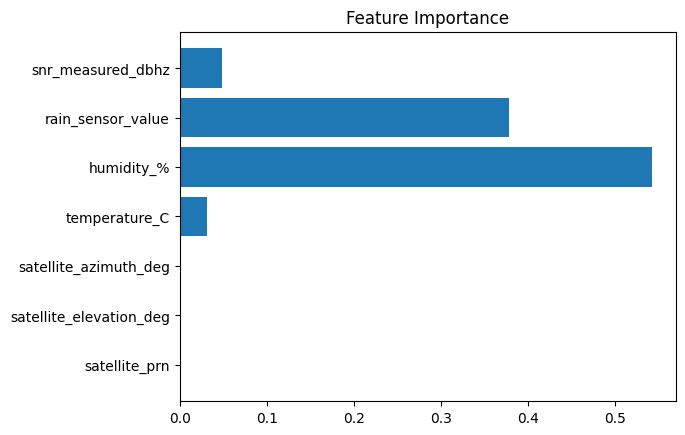

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = features.columns

plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.show()

In [43]:
import m2cgen as m2c

In [44]:
c_code = m2c.export_to_c(model)
print(c_code)

#include <string.h>
void score(double * input, double * output) {
    double var0[3];
    if (input[4] <= 65.66500091552734) {
        if (input[3] <= 28.630000114440918) {
            memcpy(var0, (double[]){0.05263157894736842, 0.9473684210526315, 0.0}, 3 * sizeof(double));
        } else {
            if (input[4] <= 64.01499938964844) {
                if (input[4] <= 62.8700008392334) {
                    if (input[4] <= 61.77499961853027) {
                        memcpy(var0, (double[]){1.0, 0.0, 0.0}, 3 * sizeof(double));
                    } else {
                        memcpy(var0, (double[]){0.9827586206896551, 0.017241379310344827, 0.0}, 3 * sizeof(double));
                    }
                } else {
                    if (input[6] <= 43.5) {
                        memcpy(var0, (double[]){0.8125, 0.1875, 0.0}, 3 * sizeof(double));
                    } else {
                        memcpy(var0, (double[]){0.9861111111111112, 0.013888888888888888, 0.0}, 3 * sizeof

In [45]:
with open("decision_tree_model.c", "w") as f:
    f.write(c_code)

In [46]:
files.download("decision_tree_model.c")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>